In [58]:
# 이상치 탐지하기
# IQR(InterQuantile Range) Q3 - Q1



In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False # -(마이너스) 기호 깨짐 방지


In [60]:
df = pd.read_csv('data/california.csv')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


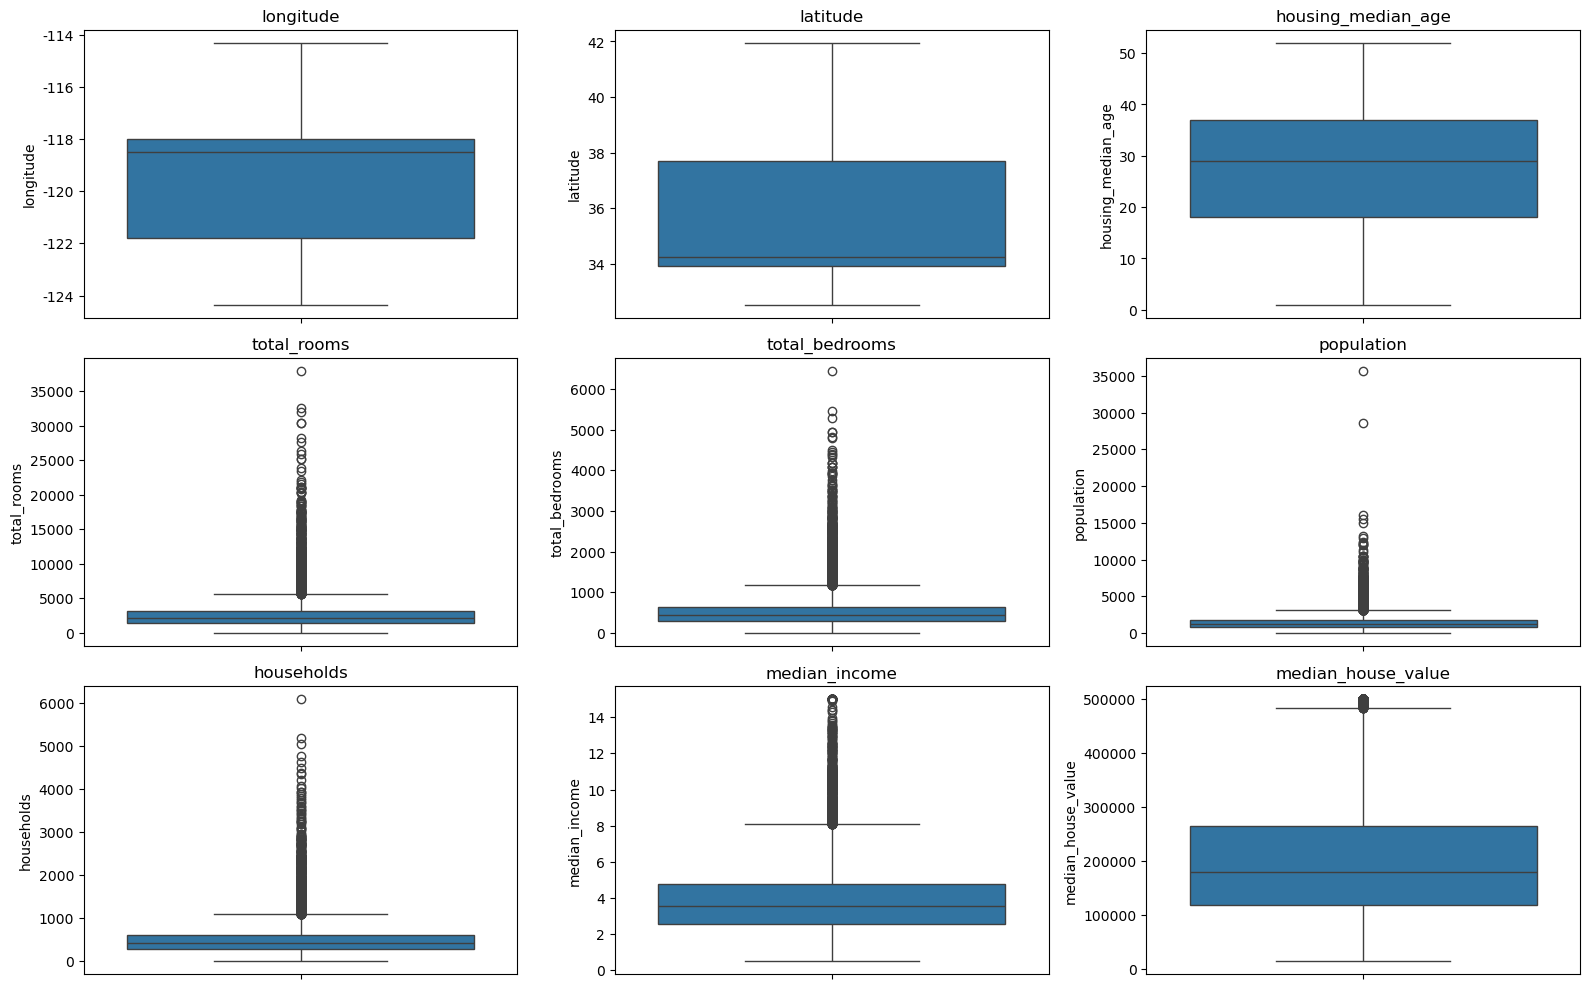

In [61]:
# 이상치들을 시각적으로 확인

cols = df.select_dtypes(include='number').columns # 수치형 컬럼들만 별도로 추림

plt.figure(figsize=(16, 10))

for i, col in enumerate(cols) : 
    plt.subplot(3, 3, i+1)
    sns.boxplot(data=df, y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

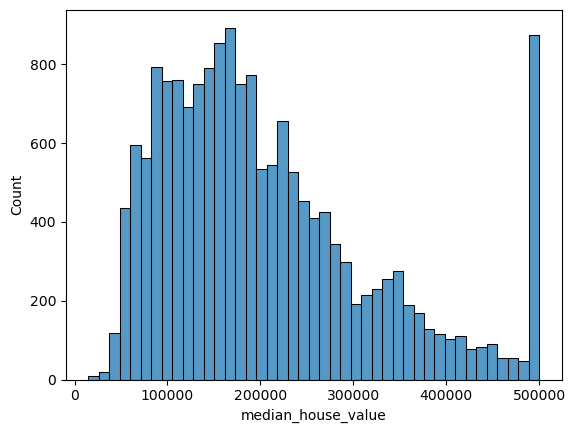

In [62]:
sns.histplot(data=df['median_house_value'])
plt.show()

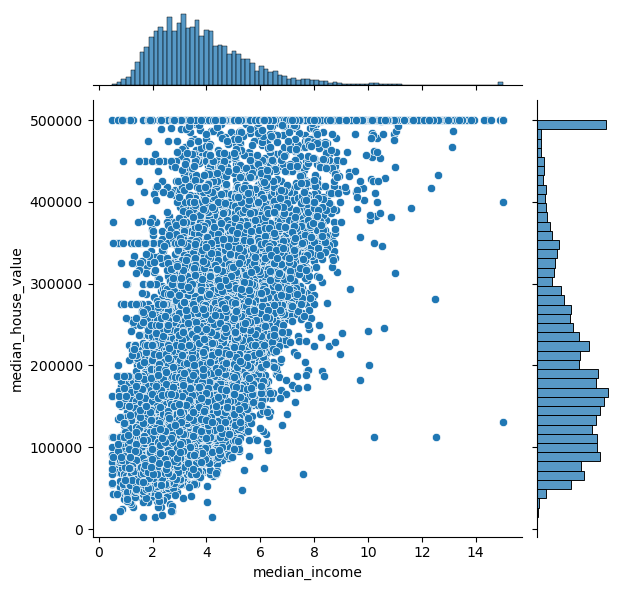

In [63]:
sns.jointplot(data=df, x='median_income', y='median_house_value')
plt.show()

In [64]:
s = pd.Series(np.arange(1,11))
s

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
dtype: int32

In [65]:
s.describe()

count    10.00000
mean      5.50000
std       3.02765
min       1.00000
25%       3.25000
50%       5.50000
75%       7.75000
max      10.00000
dtype: float64

In [66]:
Q1 = s.quantile(0.25)

print(f'Q1: {Q1}')

Q3 = s.quantile(0.75)

print(f'Q3: {Q3}')

Q1: 3.25
Q3: 7.75


In [67]:
df['median_house_value'].describe()

count     17000.000000
mean     207300.912353
std      115983.764387
min       14999.000000
25%      119400.000000
50%      180400.000000
75%      265000.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [68]:
print(f'Median House Value, Q1: {df["median_house_value"].quantile(0.25)}')
print(f'Median House Value, Q3: {df["median_house_value"].quantile(0.75)}')


Median House Value, Q1: 119400.0
Median House Value, Q3: 265000.0


In [69]:
IQR = Q3 - Q1
print(f'IQR: {IQR}')

IQR: 4.5


In [70]:
# Upper bound 와 Lower bound 값 구하기

# lower_ bound = Q1 - 1.5 * IQR
# upper_ bound = Q3 + 1.5 * IQR

lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

print(f'Lower bound : {lb}')
print(f'Upper bound : {ub}')

Lower bound : -3.5
Upper bound : 14.5


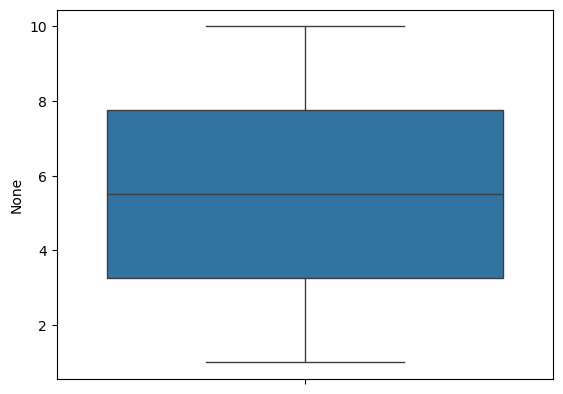

In [71]:
sns.boxplot(y=s)
plt.show()

In [72]:
Q1 = df["median_house_value"].quantile(0.25)
Q3 = df["median_house_value"].quantile(0.75)
IQR = Q3 - Q1

ub = Q3 + 1.5 * IQR
lb = Q1 - 1.5 * IQR
min =  df["median_house_value"].min()
max =  df["median_house_value"].max()

print(f'Q3 : {Q3}')
print(f'Q1 : {Q1}')

print(f'Lower bound : {lb}')
print(f'Upper bound : {ub}')
print(f'Minimum Value : {min}')
print(f'Maximum Value : {max}')

Q3 : 265000.0
Q1 : 119400.0
Lower bound : -99000.0
Upper bound : 483400.0
Minimum Value : 14999.0
Maximum Value : 500001.0


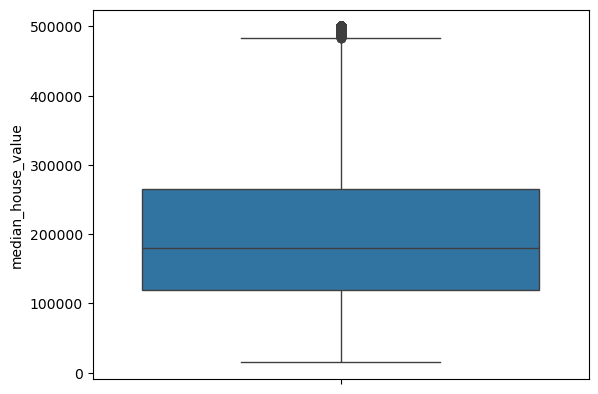

In [73]:
# 박스 플롯에서 상한선 : 이상치 값이 있으면 Upper bound값 이상치가 없으면 max값
# 박스 플롯에서 하한선 : 이상치 값이 있으면 ULower bound값 이상치가 없으면 min값

sns.boxplot(y=df['median_house_value'])
plt.show()

In [74]:
# median_house_value에서 이상치가 존재하는 행들을 추출하기

cond = (df['median_house_value'] > ub ) | (df['median_house_value'] < lb)
df[cond]['median_house_value']

215      500001.0
260      500001.0
862      500001.0
1388     500001.0
1404     500001.0
           ...   
16420    500001.0
16421    500001.0
16434    500001.0
16482    493800.0
16512    500001.0
Name: median_house_value, Length: 895, dtype: float64

In [75]:
df_iqr = df[cond]
df_iqr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
215,-116.43,33.75,24.0,2596.0,438.0,473.0,237.0,3.7727,500001.0
260,-116.55,33.84,28.0,2992.0,562.0,676.0,346.0,5.7613,500001.0
862,-117.08,34.08,34.0,45.0,11.0,39.0,14.0,3.0625,500001.0
1388,-117.17,32.69,40.0,2236.0,331.0,767.0,316.0,5.3177,500001.0
1404,-117.18,33.51,13.0,270.0,42.0,120.0,42.0,6.9930,500001.0


In [76]:
li = df_iqr.index.to_list()
df_drops = df.drop(li, axis=0)
df_drops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16105 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16105 non-null  float64
 1   latitude            16105 non-null  float64
 2   housing_median_age  16105 non-null  float64
 3   total_rooms         16105 non-null  float64
 4   total_bedrooms      16105 non-null  float64
 5   population          16105 non-null  float64
 6   households          16105 non-null  float64
 7   median_income       16105 non-null  float64
 8   median_house_value  16105 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [77]:
#이상치 제거한 데이터프레임
df_drops = df[(df['median_house_value'] <= ub) & (df['median_house_value'] >= lb) ]
df_drops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16105 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16105 non-null  float64
 1   latitude            16105 non-null  float64
 2   housing_median_age  16105 non-null  float64
 3   total_rooms         16105 non-null  float64
 4   total_bedrooms      16105 non-null  float64
 5   population          16105 non-null  float64
 6   households          16105 non-null  float64
 7   median_income       16105 non-null  float64
 8   median_house_value  16105 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [78]:
df_copy = df.copy()

df_copy['median_house_value'] = df_copy['median_house_value'].clip(lb,ub)
df_copy.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,206458.723294
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,113897.394195
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,483400.000000


In [79]:
df = pd.read_csv('data/flight.csv')

df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [80]:
# Unnamed: 0 제거하기

df = df.drop(['Unnamed: 0'],axis=1)
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [ ]:
# nmeric 컬럼 추출하기

cols = df.select_dtypes(include='number').columns
col

'median_house_value'

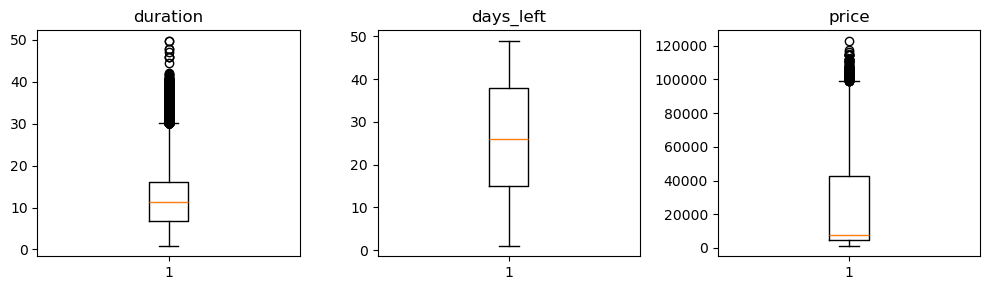

In [92]:
# numeric 컬럼들로만 boxplot 그리기

plt.figure(figsize=(10, 3))

for i , col in enumerate(cols) : 
    plt.subplot(1, 3, i+1)
    plt.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [84]:

Q1 = df['price'].quantile(.25)
Q3 = df['price'].quantile(.75)

IQR = Q3 - Q1

ub =  Q3 + 1.5 * IQR
ub =  Q1 - 1.5 * IQR

print(f'IQR : {IQR}')
print(f'Lower bound : {lb}')
print(f'Upper bound : {ub}')

display(df['price'].describe())


IQR : 37738.0
Lower bound : -99000.0
Upper bound : -51824.0


count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

In [ ]:
#전처리
#1.결측치 처리
#2.이상치 처리
#3.인코딩(문자형 데이터를 수치형 데이터로 변환)
#4.스케일링(Standard,MinMaxScale,RobustScale)
#5.자르기(Split) : 학습데이터(훈련)와 검증데이터로 분리


